In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import mannwhitneyu

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)

# ***PS1***

# **Step 1 — Load data**

In [2]:
BASE_PATH = "/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset"

features_path = os.path.join(BASE_PATH, "elliptic_txs_features.csv")
classes_path  = os.path.join(BASE_PATH, "elliptic_txs_classes.csv")
edges_path    = os.path.join(BASE_PATH, "elliptic_txs_edgelist.csv")

df_features = pd.read_csv(features_path, header=None)
df_classes  = pd.read_csv(classes_path)
df_edges    = pd.read_csv(edges_path)

print(df_features.shape, df_classes.shape, df_edges.shape)
df_features.head()

(203769, 167) (203769, 2) (234355, 2)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,-0.167933,-0.049707,-0.164402,-0.028741,-0.035391,-0.042955,-0.013282,-0.057195,-0.169609,-0.171154,-0.174473,-1.373657,-1.371460,-0.139731,-0.148912,-0.080147,-0.155661,-0.010763,-0.012107,-0.139733,-0.148907,-0.080147,-0.155661,-0.010669,-0.012005,-0.024669,-0.031272,-0.023045,-0.026215,0.001428,0.001483,-0.227215,-0.239368,-0.075256,-0.234952,0.037468,0.043444,-0.227203,-0.243236,-0.097895,-0.235896,0.036577,0.042345,-0.414005,-0.488340,-0.232553,-0.467554,0.048767,0.052956,-0.039149,-0.172895,-0.163126,-0.160932,-1.316342,-1.315388,-0.039144,-0.172884,-0.163115,-0.160925,-1.316333,-1.315375,-0.017032,-0.030026,-0.017640,-0.015071,-0.140763,-0.140335,-0.095403,-0.264376,-0.250523,-0.263703,1.133527,1.135947,-0.059013,-0.262368,-0.255111,-0.259194,1.125590,1.128038,-0.293773,-0.159732,0.034039,-0.183816,1.135523,1.135279,-0.169160,-0.201584,-0.116817,-0.191472,-0.014659,-0.018849,-1.457953,-1.494057,-0.083459,-1.485972,-0.088798,-0.090437,-0.166550,-0.216536,-0.134546,-0.194817,-0.003175,-0.004094,-1.096336,-1.267340,-0.349933,-1.230441,-0.004358,-0.004194,-0.116425,-0.176617,-0.137323,-0.152464,-0.026060,-0.027660,-0.093145,-0.143707,-0.097719,-0.127462,0.003143,0.002426,-0.120950,-0.199145,-0.187993,-0.212948,1.064205,1.063787,-1.373782,-1.354735,-0.297975,-1.403698,1.342003,1.340733,-0.171601,-0.458162,-0.423588,-0.440883,-1.015963,-1.016230,-0.968903,-0.375715,0.759748,-0.768329,1.488113,1.487932,-0.216814,-0.605631,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,-0.167948,-0.049707,-0.164417,-0.028741,-0.035391,-0.042955,-0.013282,-0.055327,-0.169757,-0.171477,-0.174490,0.887058,0.884557,-0.139731,-0.148912,-0.080147,-0.155661,-0.010763,-0.012107,-0.139733,-0.148907,-0.080147,-0.155661,-0.010669,-0.012005,-0.024669,-0.031272,-0.023045,-0.026215,0.001428,0.001483,-0.227215,-0.239368,-0.075256,-0.234952,0.037468,0.043444,-0.227203,-0.243236,-0.097895,-0.235896,0.036577,0.042345,-0.413965,-0.488307,-0.232553,-0.467516,0.048767,0.052956,-0.039151,-0.172895,-0.163126,-0.160933,0.923473,0.923011,-0.039146,-0.172884,-0.163114,-0.160926,0.923516,0.923110,-0.017032,-0.030026,-0.017640,-0.015071,-0.140763,-0.140335,-0.095403,-0.264425,-0.250574,-0.263753,-0.169119,-0.167165,-0.059013,-0.262424,-0.255168,-0.259251,-0.187191,-0.185274,-0.293692,-0.760700,-0.692777,-0.719789,-1.084907,-1.084845,-0.170113,-0.202332,-0.116817,-0.192405,-0.014659,-0.018849,-1.457921,-1.494024,-0.083459,-1.485939,-0.088798,-0.090437,-0.166550,-0.216536,-0.134546,-0.194817,-0.003175,-0.004094,-1.096336,-1.267340,-0.349933,-1.230441,-0.004358,-0.004194,-0.116425,-0.176617,-0.137323,-0.152464,-0.026060,-0.027660,-0.093145,-0.143707,-0.097719,-0.127462,0.003143,0.002426,-0.121330,-0.110933,-0.075909,-0.111641,-1.159649,-1.160129,-1.373723,-1.353918,-0.295982,-1.403215,-0.975738,-0.975237,-0.168742,-0.263290,-0.186389,-0.250875,-1.015963,-1.016230,-0.968903,0.146997,1.366287,-0.464773,-1.116918,-1.116948,-0.216814,0.634272,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,-0.168576,-0.049707,-0.165054,-0.028741,-0.035391,-0.042955,-0.013282,

# **Step 2 — Rename columns and prepare node table**

In [3]:
# Gán tên cho cột
feature_cols = ["txId", "time_step"] + [f"f_{i}" for i in range(2, df_features.shape[1])]
df_features.columns = feature_cols

df_nodes = df_features[["txId", "time_step"]].copy()

class_map = {
    "1": "illicit",
    "2": "licit",
    "unknown": "unknown"
}

df_classes["class"] = df_classes["class"].astype(str)  #Chuẩn hóa kiểu dữ liệu
df_classes["class_label"] = df_classes["class"].map(class_map)  #Map label

# merge node với label
df_nodes = df_nodes.merge(df_classes, on="txId", how="left")
# Gộp:        df_nodes (txId, time_step)               df_classes (txId, label)

print(df_nodes["class_label"].value_counts(dropna=False))
df_nodes.head()

class_label
unknown    157205
licit       42019
illicit      4545
Name: count, dtype: int64


,txId,time_step,class,class_label
0,230425980,1,unknown,unknown
1,5530458,1,unknown,unknown
2,232022460,1,unknown,unknown
3,232438397,1,2,licit
4,230460314,1,unknown,unknown


# **Step 3 — Build directed graph**

In [4]:
# Tạo một directed graph (đồ thị có hướng) bằng NetworkX
G = nx.DiGraph()

# add all nodes first
G.add_nodes_from(df_nodes["txId"].tolist())

# add directed edges
edge_list = list(zip(df_edges["txId1"], df_edges["txId2"]))  #Transaction 2 sử dụng output từ transaction 1
G.add_edges_from(edge_list)

print(f"Number of nodes: {G.number_of_nodes():,}")
print(f"Number of edges: {G.number_of_edges():,}")

print(f"Weakly connected components: {nx.number_weakly_connected_components(G):,}")
# 49 components = 49 time steps => KHÔNG có edge nối giữa các time step
# G = G₁ ∪ G₂ ∪ G₃ ... G₄₉

Number of nodes: 203,769
Number of edges: 234,355
Weakly connected components: 49


# **Step 4 — Compute PS1 metrics (label-free)**

In [6]:
in_deg_dict = dict(G.in_degree())
out_deg_dict = dict(G.out_degree())

# Tạo DataFrame để xem
degree_df = pd.DataFrame({
    "txId": list(G.nodes()),
    "in_degree": [in_deg_dict[n] for n in G.nodes()],
    "out_degree": [out_deg_dict[n] for n in G.nodes()],
})

degree_df["total_degree"] = degree_df["in_degree"] + degree_df["out_degree"]

degree_df["asymmetry"] = np.where(
    degree_df["total_degree"] > 0,       #tránh chia cho 0
    (degree_df["in_degree"] - degree_df["out_degree"]) / degree_df["total_degree"],
    np.nan
)

degree_df["abs_asymmetry"] = degree_df["asymmetry"].abs()

degree_df.head()


degree_df.to_csv("degree_metrics.csv", index=False)  # ịn ra file kết quả nè

# **Step 5 — Global graph statistics (label-free)**

In [7]:
global_stats = degree_df[["in_degree", "out_degree", "total_degree", "asymmetry", "abs_asymmetry"]].describe()
display(global_stats)

pure_sinks = ((degree_df["in_degree"] > 0) & (degree_df["out_degree"] == 0)).mean()
pure_sources = ((degree_df["out_degree"] > 0) & (degree_df["in_degree"] == 0)).mean()

print(f"Fraction of pure sinks   (in>0, out=0): {pure_sinks:.4f}")
print(f"Fraction of pure sources (out>0, in=0): {pure_sources:.4f}")

,in_degree,out_degree,total_degree,asymmetry,abs_asymmetry
count,203769.000000,203769.000000,203769.000000,203769.000000,203769.000000
mean,1.150101,1.150101,2.300203,-0.108612,0.521818
std,3.911132,1.894740,4.328377,0.687363,0.460401
min,0.000000,0.000000,1.000000,-1.000000,0.000000
25%,0.000000,1.000000,1.000000,-1.000000,0.000000
50%,1.000000,1.000000,2.000000,0.000000,0.333333
75%,1.000000,1.000000,2.000000,0.000000,1.000000
max,284.000000,472.000000,473.000000,1.000000,1.000000


Fraction of pure sinks   (in>0, out=0): 0.1837
Fraction of pure sources (out>0, in=0): 0.2715


# **Step 6 — Merge metrics with labels for post-hoc evaluation**

In [8]:
# Gán label vào kết quả bên trên
ps1_df = degree_df.merge(
    df_nodes[["txId", "time_step", "class_label"]],
    on="txId",
    how="left"
)

print(ps1_df.shape)   # kiểm tra shape, Số node KHÔNG thay đổi
print(ps1_df["class_label"].value_counts(dropna=False))     # Distribution của label
ps1_df.head()

(203769, 8)
class_label
unknown    157205
licit       42019
illicit      4545
Name: count, dtype: int64


,txId,in_degree,out_degree,total_degree,asymmetry,abs_asymmetry,time_step,class_label
0,230425980,1,1,2,0.000000,0.000000,1,unknown
1,5530458,1,1,2,0.000000,0.000000,1,unknown
2,232022460,1,2,3,-0.333333,0.333333,1,unknown
3,232438397,160,1,161,0.987578,0.987578,1,licit
4,230460314,2,8,10,-0.600000,0.600000,1,unknown


# **Step 7 — Group statistics by class**

In [9]:
group_stats = ps1_df.groupby("class_label")[["in_degree", "out_degree", "total_degree", "asymmetry", "abs_asymmetry"]].agg(
    ["count", "mean", "median", "std"]
)

display(group_stats)

in_degree                            out_degree                   \
                count      mean median       std      count      mean median   
class_label                                                                    
illicit          4545  1.269967    1.0  7.215218       4545  0.741694    1.0   
licit           42019  1.909398    1.0  7.122538      42019  1.185821    1.0   
unknown        157205  0.943685    1.0  2.136958     157205  1.152362    1.0   

                      total_degree                            asymmetry  \
                  std        count      mean median       std     count   
class_label                                                               
illicit      0.571620         4545  2.011661    1.0  7.177521      4545   
licit        3.246769        42019  3.095219    2.0  7.782942     42019   
unknown      1.349530       157205  2.096047    2.0  2.528148    157205   

                                       abs_asymmetry                      \
                 mean median       std         count      mean    median   
class_label                                                                
illicit      0.056396    0.0  0.771688          4545  0.610412  1.000000   
licit       -0.069129    0.0  0.785764         42019  0.662210  1.000000   
unknown     -0.123936    0.0  0.654778        157205  0.481732  0.333333   

                       
                  std  
class_label            
illicit      0.475394  
licit        0.428570  
unknown      0.460464

# **Step 8 — Mann–Whitney U test + rank-biserial correlation**

In [10]:
# Hàm effect size, rank-biserial correlation (RBC) đo độ mạnh của sự khác biệt (đổi từ u_stat qua cái nì)
# >0 nhóm 1 > nhóm 2 , <0  nhóm 1 < nhóm 2, gần ±1  khác rất mạnh

def rank_biserial_from_u(u_stat, n1, n2):
    return 1 - (2 * u_stat) / (n1 * n2)

def mannwhitney_test(df, metric, group_col="class_label", g1="licit", g2="illicit"):
    x = df.loc[df[group_col] == g1, metric].dropna()
    y = df.loc[df[group_col] == g2, metric].dropna()

# Tính effect size
# u = số lần một phần tử nhóm này thắng phần tử nhóm kia (rank)
    # số lần giá trị trong x < y
    u_stat, p_val = mannwhitneyu(x, y, alternative="two-sided")
    # Chạy Mann–Whitney U test hai phía u_stat: thống kê U và p_value
    rbc = rank_biserial_from_u(u_stat, len(x), len(y))
    
    return {
        "metric": metric,
        "n_licit": len(x),
        "n_illicit": len(y),
        "median_licit": x.median(),
        "median_illicit": y.median(),
        "u_stat": u_stat,
        "p_value": p_val,
        "rank_biserial_corr": rbc
    }

# Lặp qua từng metric, chạy test, rồi gom kết quả thành DataFrame
metrics_to_test = ["in_degree", "out_degree", "total_degree", "asymmetry", "abs_asymmetry"]

mw_results = pd.DataFrame([mannwhitney_test(ps1_df, m) for m in metrics_to_test])
display(mw_results)

,metric,n_licit,n_illicit,median_licit,median_illicit,u_stat,p_value,rank_biserial_corr
0,in_degree,42019,4545,1.0,1.0,100682787.5,5.552428e-11,-0.054401
1,out_degree,42019,4545,1.0,1.0,113640517.5,1.441678e-118,-0.190100
2,total_degree,42019,4545,2.0,1.0,119280225.5,6.844822e-188,-0.249162
3,asymmetry,42019,4545,0.0,0.0,86621821.5,1.628183e-26,0.092853
4,abs_asymmetry,42019,4545,1.0,1.0,99639397.0,5.797299e-08,-0.043474


# **Step 9 — Enrichment analysis**

**9.1 Baseline illicit rate among labeled nodes**

In [11]:
labeled_df = ps1_df[ps1_df["class_label"].isin(["licit", "illicit"])].copy()

baseline_illicit = (labeled_df["class_label"] == "illicit").mean()
print(f"Baseline illicit rate (labeled only): {baseline_illicit:.4f}")

Baseline illicit rate (labeled only): 0.0976


**9.2 Helper function for enrichment**

In [12]:
# Hàm enrichment_ratio
# df_subset: 1 nhóm node mk chọn (ví dụ asymmetry cao)
def enrichment_ratio(df_subset, class_col="class_label", positive_label="illicit", baseline=0.0):
 
    # lọc node có label   
    labeled_subset = df_subset[df_subset[class_col].isin(["licit", "illicit"])].copy()
    
    if len(labeled_subset) == 0:
        return {
            "n_subset_labeled": 0,
            "illicit_rate_subset": np.nan,
            "baseline_illicit_rate": baseline,
            "enrichment_ratio": np.nan
        }

# tính illicit rate trong subset
    illicit_rate_subset = (labeled_subset[class_col] == positive_label).mean()

# tính enrichment
    enrichment = illicit_rate_subset / baseline if baseline > 0 else np.nan
    
    return {
        "n_subset_labeled": len(labeled_subset),
        "illicit_rate_subset": illicit_rate_subset,
        "baseline_illicit_rate": baseline,
        "enrichment_ratio": enrichment
    }

**9.3 Extreme imbalance / accumulator / distributor**

In [13]:
threshold_results = []

# extreme imbalance
subset_extreme = ps1_df[ps1_df["asymmetry"] > 0.95]
res_extreme = enrichment_ratio(subset_extreme, baseline=baseline_illicit)
res_extreme["rule"] = "asymmetry > 0.95"
threshold_results.append(res_extreme)

# accumulators
subset_acc = ps1_df[ps1_df["asymmetry"] > 0.5]
res_acc = enrichment_ratio(subset_acc, baseline=baseline_illicit)
res_acc["rule"] = "asymmetry > 0.5"
threshold_results.append(res_acc)

# distributors
subset_dist = ps1_df[ps1_df["asymmetry"] < -0.5]
res_dist = enrichment_ratio(subset_dist, baseline=baseline_illicit)
res_dist["rule"] = "asymmetry < -0.5"
threshold_results.append(res_dist)

enrichment_df = pd.DataFrame(threshold_results)[[
    "rule", "n_subset_labeled", "illicit_rate_subset", "baseline_illicit_rate", "enrichment_ratio"
]]

display(enrichment_df)

,rule,n_subset_labeled,illicit_rate_subset,baseline_illicit_rate,enrichment_ratio
0,asymmetry > 0.95,11861,0.124863,0.097608,1.279234
1,asymmetry > 0.5,13372,0.112100,0.097608,1.148475
2,asymmetry < -0.5,15575,0.077368,0.097608,0.792639


# **Step 10 — Vẽ và chi tiết các mức thredholds**

Baseline illicit rate = 0.0976


,threshold,side,rule,n_subset_total,n_subset_labeled,actual_illicit_count,expected_illicit_count,illicit_rate_subset,baseline_illicit_rate,enrichment_ratio,lift_count
0,-1.00,left (distributor side),asymmetry <= -1.00,55322,15156,1205,1479.340692,0.079506,0.097608,0.814552,-274.340692
1,-0.95,left (distributor side),asymmetry <= -0.95,55333,15162,1205,1479.926338,0.079475,0.097608,0.814230,-274.926338
2,-0.90,left (distributor side),asymmetry <= -0.90,55377,15167,1205,1480.414376,0.079449,0.097608,0.813961,-275.414376
3,-0.85,left (distributor side),asymmetry <= -0.85,55468,15196,1205,1483.244996,0.079297,0.097608,0.812408,-278.244996
4,-0.80,left (distributor side),asymmetry <= -0.80,55641,15260,1205,1489.491882,0.078965,0.097608,0.809001,-284.491882
5,-0.75,left (distributor side),asymmetry <= -0.75,55840,15318,1205,1495.153123,0.078666,0.097608,0.805938,-290.153123
6,-0.70,left (distributor side),asymmetry <= -0.70,56050,15369,1205,1500.131110,0.078405,0.097608,0.803263,-295.131110
7,-0.65,left (distributor side),asymmetry <= -0.65,56367,15445,1205,1507.549287,0.078019,0.097608,0.799311,-302.549287
8,-0.60,left (distributor side),asymmetry <= -0.60,56965,15567,1205,1519.457413,0.077407,0.097608,0.793046,-314.457413
9,-0.55,left (distributor side),asymmetry <= -0.55,56996,15575,1205,1520.238274,0.077368,0.097608,0.792639,-315.238274


,threshold,side,rule,n_subset_total,n_subset_labeled,actual_illicit_count,expected_illicit_count,illicit_rate_subset,baseline_illicit_rate,enrichment_ratio,lift_count
31,0.55,right (accumulator side),asymmetry >= 0.55,39935,13371,1499,1305.111137,0.112108,0.097608,1.148561,193.888863
32,0.60,right (accumulator side),asymmetry >= 0.60,39895,13351,1499,1303.158985,0.112276,0.097608,1.150282,195.841015
33,0.65,right (accumulator side),asymmetry >= 0.65,39259,13064,1488,1275.145606,0.113901,0.097608,1.166926,212.854394
34,0.70,right (accumulator side),asymmetry >= 0.70,38847,12846,1483,1253.867151,0.115444,0.097608,1.182741,229.132849
35,0.75,right (accumulator side),asymmetry >= 0.75,38579,12656,1482,1235.321708,0.117099,0.097608,1.199687,246.678292
36,0.80,right (accumulator side),asymmetry >= 0.80,38258,12435,1482,1213.750430,0.119180,0.097608,1.221009,268.249570
37,0.85,right (accumulator side),asymmetry >= 0.85,37907,12166,1481,1187.493987,0.121733,0.097608,1.247164,293.506013
38,0.90,right (accumulator side),asymmetry >= 0.90,37732,12029,1481,1174.121746,0.123119,0.097608,1.261368,306.878254
39,0.95,right (accumulator side),asymmetry >= 0.95,37523,11861,1481,1157.723671,0.124863,0.097608,1.279234,323.276329
40,1.00,right (accumulator side),asymmetry >= 1.00,37424,11785,1480,1150.305494,0.125583,0.097608,1.286615,329.694506


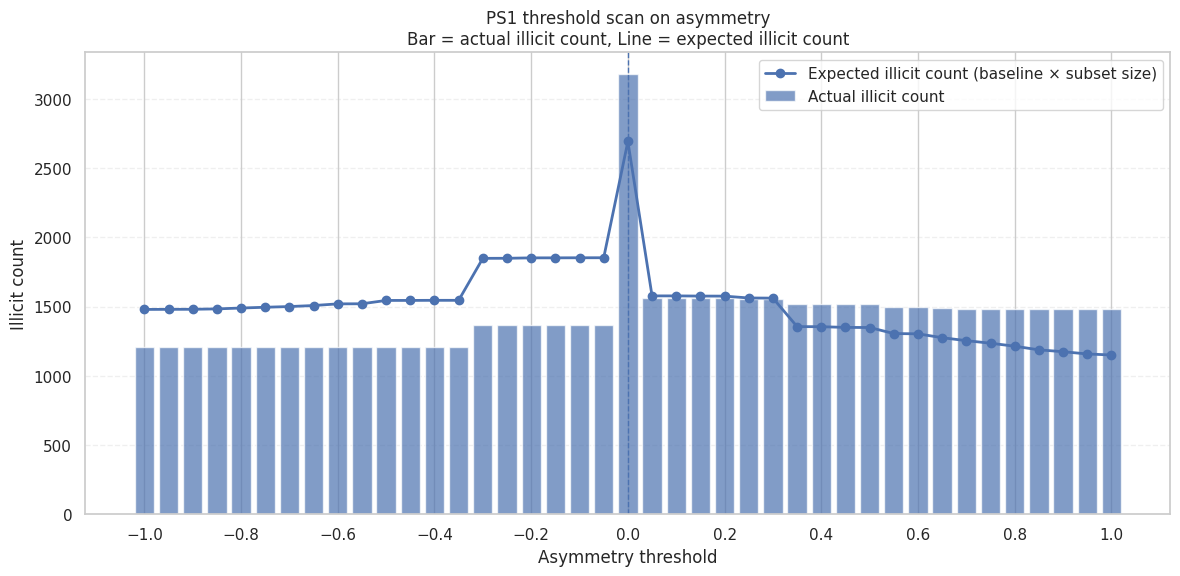

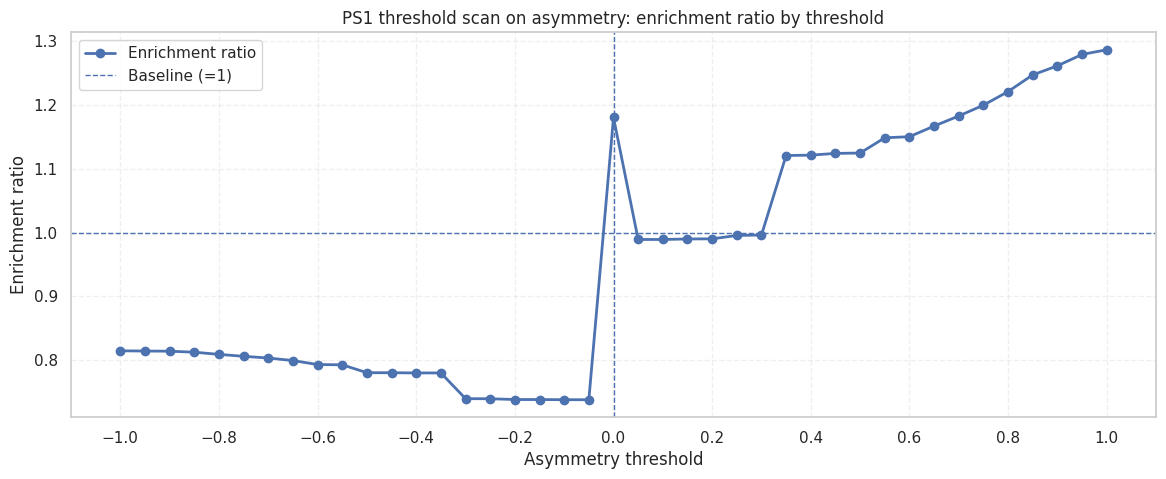


Top thresholds by enrichment ratio:


,threshold,side,rule,n_subset_total,n_subset_labeled,actual_illicit_count,expected_illicit_count,illicit_rate_subset,baseline_illicit_rate,enrichment_ratio,lift_count
40,1.00,right (accumulator side),asymmetry >= 1.00,37424,11785,1480,1150.305494,0.125583,0.097608,1.286615,329.694506
39,0.95,right (accumulator side),asymmetry >= 0.95,37523,11861,1481,1157.723671,0.124863,0.097608,1.279234,323.276329
38,0.90,right (accumulator side),asymmetry >= 0.90,37732,12029,1481,1174.121746,0.123119,0.097608,1.261368,306.878254
37,0.85,right (accumulator side),asymmetry >= 0.85,37907,12166,1481,1187.493987,0.121733,0.097608,1.247164,293.506013
36,0.80,right (accumulator side),asymmetry >= 0.80,38258,12435,1482,1213.750430,0.119180,0.097608,1.221009,268.249570
35,0.75,right (accumulator side),asymmetry >= 0.75,38579,12656,1482,1235.321708,0.117099,0.097608,1.199687,246.678292
34,0.70,right (accumulator side),asymmetry >= 0.70,38847,12846,1483,1253.867151,0.115444,0.097608,1.182741,229.132849
20,0.00,right (accumulator side),asymmetry >= 0.00,124046,27583,3178,2692.310261,0.115216,0.097608,1.180399,485.689739
33,0.65,right (accumulator side),asymmetry >= 0.65,39259,13064,1488,1275.145606,0.113901,0.097608,1.166926,212.854394
32,0.60,right (accumulator side),asymmetry >= 0.60,39895,13351,1499,1303.158985,0.112276,0.097608,1.150282,195.841015



Top thresholds by illicit count lift (actual - expected):


,threshold,side,rule,n_subset_total,n_subset_labeled,actual_illicit_count,expected_illicit_count,illicit_rate_subset,baseline_illicit_rate,enrichment_ratio,lift_count
20,0.00,right (accumulator side),asymmetry >= 0.00,124046,27583,3178,2692.310261,0.115216,0.097608,1.180399,485.689739
40,1.00,right (accumulator side),asymmetry >= 1.00,37424,11785,1480,1150.305494,0.125583,0.097608,1.286615,329.694506
39,0.95,right (accumulator side),asymmetry >= 0.95,37523,11861,1481,1157.723671,0.124863,0.097608,1.279234,323.276329
38,0.90,right (accumulator side),asymmetry >= 0.90,37732,12029,1481,1174.121746,0.123119,0.097608,1.261368,306.878254
37,0.85,right (accumulator side),asymmetry >= 0.85,37907,12166,1481,1187.493987,0.121733,0.097608,1.247164,293.506013
36,0.80,right (accumulator side),asymmetry >= 0.80,38258,12435,1482,1213.750430,0.119180,0.097608,1.221009,268.249570
35,0.75,right (accumulator side),asymmetry >= 0.75,38579,12656,1482,1235.321708,0.117099,0.097608,1.199687,246.678292
34,0.70,right (accumulator side),asymmetry >= 0.70,38847,12846,1483,1253.867151,0.115444,0.097608,1.182741,229.132849
33,0.65,right (accumulator side),asymmetry >= 0.65,39259,13064,1488,1275.145606,0.113901,0.097608,1.166926,212.854394
32,0.60,right (accumulator side),asymmetry >= 0.60,39895,13351,1499,1303.158985,0.112276,0.097608,1.150282,195.841015


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===== 1) Baseline illicit rate trên toàn bộ labeled data =====
labeled_all = ps1_df[ps1_df["class_label"].isin(["licit", "illicit"])].copy()
baseline_illicit = (labeled_all["class_label"] == "illicit").mean()

print(f"Baseline illicit rate = {baseline_illicit:.4f}")

# ===== 2) Hàm scan threshold =====
def scan_asymmetry_thresholds(
    df,
    metric_col="asymmetry",
    class_col="class_label",
    positive_label="illicit",
    thresholds=None
):
    if thresholds is None:
        thresholds = np.round(np.arange(-1.0, 1.01, 0.05), 2)

    results = []

    for t in thresholds:
        # Quy tắc cắt:
        # t < 0  -> lấy phía trái: asymmetry <= t
        # t >= 0 -> lấy phía phải: asymmetry >= t
        if t < 0:
            subset = df[df[metric_col] <= t].copy()
            side = "left (distributor side)"
            rule = f"{metric_col} <= {t:.2f}"
        else:
            subset = df[df[metric_col] >= t].copy()
            side = "right (accumulator side)"
            rule = f"{metric_col} >= {t:.2f}"

        labeled_subset = subset[subset[class_col].isin(["licit", "illicit"])].copy()
        n_labeled = len(labeled_subset)

        actual_illicit_count = (labeled_subset[class_col] == positive_label).sum()
        illicit_rate_subset = (
            actual_illicit_count / n_labeled if n_labeled > 0 else np.nan
        )

        expected_illicit_count = (
            baseline_illicit * n_labeled if n_labeled > 0 else np.nan
        )

        enrichment_ratio = (
            illicit_rate_subset / baseline_illicit
            if (n_labeled > 0 and baseline_illicit > 0)
            else np.nan
        )

        lift_count = (
            actual_illicit_count - expected_illicit_count
            if n_labeled > 0 else np.nan
        )

        results.append({
            "threshold": t,
            "side": side,
            "rule": rule,
            "n_subset_total": len(subset),
            "n_subset_labeled": n_labeled,
            "actual_illicit_count": actual_illicit_count,
            "expected_illicit_count": expected_illicit_count,
            "illicit_rate_subset": illicit_rate_subset,
            "baseline_illicit_rate": baseline_illicit,
            "enrichment_ratio": enrichment_ratio,
            "lift_count": lift_count
        })

    return pd.DataFrame(results)

# ===== 3) Chạy scan =====
thresholds = np.round(np.arange(-1.0, 1.01, 0.05), 2)
scan_df = scan_asymmetry_thresholds(
    ps1_df,
    metric_col="asymmetry",
    class_col="class_label",
    positive_label="illicit",
    thresholds=thresholds
)

display(scan_df.head(10))
display(scan_df.tail(10))

# ===== 4) Vẽ combo chart: Bar = illicit thực, Line = illicit kỳ vọng =====
fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(
    scan_df["threshold"],
    scan_df["actual_illicit_count"],
    width=0.04,
    alpha=0.7,
    label="Actual illicit count"
)

ax.plot(
    scan_df["threshold"],
    scan_df["expected_illicit_count"],
    marker="o",
    linewidth=2,
    label="Expected illicit count (baseline × subset size)"
)

ax.axvline(0, linestyle="--", linewidth=1)
ax.set_xlabel("Asymmetry threshold")
ax.set_ylabel("Illicit count")
ax.set_title("PS1 threshold scan on asymmetry\nBar = actual illicit count, Line = expected illicit count")
ax.legend()
plt.xticks(np.arange(-1, 1.1, 0.2))
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.show()

# ===== 5) Thêm chart phụ để chọn threshold dễ hơn: enrichment ratio =====
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    scan_df["threshold"],
    scan_df["enrichment_ratio"],
    marker="o",
    linewidth=2,
    label="Enrichment ratio"
)

ax.axhline(1, linestyle="--", linewidth=1, label="Baseline (=1)")
ax.axvline(0, linestyle="--", linewidth=1)
ax.set_xlabel("Asymmetry threshold")
ax.set_ylabel("Enrichment ratio")
ax.set_title("PS1 threshold scan on asymmetry: enrichment ratio by threshold")
ax.legend()
plt.xticks(np.arange(-1, 1.1, 0.2))
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

# ===== 6) Gợi ý threshold 'tốt' theo vài tiêu chí =====
# (A) enrichment cao nhất nhưng yêu cầu có đủ mẫu labeled
min_labeled = 30
best_enrichment = (
    scan_df[scan_df["n_subset_labeled"] >= min_labeled]
    .sort_values(["enrichment_ratio", "actual_illicit_count"], ascending=[False, False])
    .head(10)
)

# (B) lift_count cao nhất: số illicit thực vượt kỳ vọng nhiều nhất
best_lift = (
    scan_df[scan_df["n_subset_labeled"] >= min_labeled]
    .sort_values(["lift_count", "enrichment_ratio"], ascending=[False, False])
    .head(10)
)

print("\nTop thresholds by enrichment ratio:")
display(best_enrichment)

print("\nTop thresholds by illicit count lift (actual - expected):")
display(best_lift)

# Step 11 — PS1 summary table 

In [15]:
summary_table = ps1_df.groupby("class_label")[["in_degree", "out_degree", "total_degree", "asymmetry", "abs_asymmetry"]].median().reset_index()
display(summary_table)

display(mw_results)
display(enrichment_df)

,class_label,in_degree,out_degree,total_degree,asymmetry,abs_asymmetry
0,illicit,1.0,1.0,1.0,0.0,1.000000
1,licit,1.0,1.0,2.0,0.0,1.000000
2,unknown,1.0,1.0,2.0,0.0,0.333333


,metric,n_licit,n_illicit,median_licit,median_illicit,u_stat,p_value,rank_biserial_corr
0,in_degree,42019,4545,1.0,1.0,100682787.5,5.552428e-11,-0.054401
1,out_degree,42019,4545,1.0,1.0,113640517.5,1.441678e-118,-0.190100
2,total_degree,42019,4545,2.0,1.0,119280225.5,6.844822e-188,-0.249162
3,asymmetry,42019,4545,0.0,0.0,86621821.5,1.628183e-26,0.092853
4,abs_asymmetry,42019,4545,1.0,1.0,99639397.0,5.797299e-08,-0.043474


,rule,n_subset_labeled,illicit_rate_subset,baseline_illicit_rate,enrichment_ratio
0,asymmetry > 0.95,11861,0.124863,0.097608,1.279234
1,asymmetry > 0.5,13372,0.112100,0.097608,1.148475
2,asymmetry < -0.5,15575,0.077368,0.097608,0.792639
